# Bird Sound Classification — YAMNet Embeddings + Classical ML

**Drive-backed, restart-safe pipeline.**

Approach: extract 1024-dim audio embeddings using Google's pretrained YAMNet model, then train classical ML classifiers (SVM, MLP, RandomForest) on top. Comparison baseline to the MobileNetV2 spectrogram-CNN approach.

Pipeline:
1. Drive mount + config
2. Dataset download (cached)
3. EDA on metadata CSV
4. Load YAMNet + extract embeddings (cached to Drive)
5. Filter rare species + label encode
6. Train/val/test split (stratified with fallback)
7. Feature scaling
8. Train SVM, MLP, Random Forest (checkpoints on Drive)
9. Model comparison + per-species evaluation
10. Save all artifacts + metrics
11. Prediction pipeline


## 1. Drive mount + config

All paths, seeds, and hyperparameters live here so ablations for the paper are one-line changes.

In [1]:
import os

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted.")
else:
    print("Drive already mounted.")

# ---- Drive-backed project folder ----
DRIVE_ROOT = '/content/drive/MyDrive/BirdSound114_YAMNet'
os.makedirs(DRIVE_ROOT, exist_ok=True)

# ---- Cache paths on Drive (survive restarts) ----
DRIVE_KAGGLE_JSON = f'{DRIVE_ROOT}/kaggle.json'
DRIVE_EMBEDDINGS  = f'{DRIVE_ROOT}/yamnet_embeddings.csv'
DRIVE_SKIPPED     = f'{DRIVE_ROOT}/yamnet_skipped.csv'
DRIVE_SVM_MODEL   = f'{DRIVE_ROOT}/svm_model.pkl'
DRIVE_MLP_MODEL   = f'{DRIVE_ROOT}/mlp_model.pkl'
DRIVE_RF_MODEL    = f'{DRIVE_ROOT}/rf_best_model.pkl'
DRIVE_SCALER      = f'{DRIVE_ROOT}/scaler.pkl'
DRIVE_LABEL_ENC   = f'{DRIVE_ROOT}/label_encoder.pkl'
DRIVE_METRICS     = f'{DRIVE_ROOT}/final_metrics.json'
DRIVE_REPORT_CSV  = f'{DRIVE_ROOT}/per_species_accuracy.csv'
DRIVE_CM_PNG      = f'{DRIVE_ROOT}/confusion_matrix.png'
DRIVE_COMPARE_PNG = f'{DRIVE_ROOT}/model_comparison.png'

# ---- Local (fast SSD) paths ----
DATA_DIR   = '/content/birds114'
AUDIO_DIR  = f'{DATA_DIR}/Voice of Birds/Voice of Birds'
CSV_PATH   = f'{DATA_DIR}/Birds Voice.csv'
KAGGLE_ZIP = '/content/sound-of-114-species-of-birds-till-2022.zip'

# ---- Hyperparameters (change here for ablations) ----
SEED = 42
YAMNET_SR = 16000
MIN_SAMPLES_PER_CLASS = 5     # YAMNet embeddings work better with slightly more samples
TEST_SIZE  = 0.15             # 70/15/15 split
VAL_SIZE   = 0.15

# Model hyperparameters
SVM_C = 10
SVM_GAMMA = "scale"
MLP_HIDDEN = (512, 256)
MLP_MAX_ITER = 300            # was 20 in original — WAY too low, silent underperformance
RF_GRID = {
    "n_estimators": [200, 400],       # trimmed from [200, 300, 400, 500]
    "max_depth":    [40, None],       # trimmed from [20, 40, 60, None]
    "max_features": ["sqrt"],         # trimmed from ["sqrt", "log2"]
}
SKIP_RF_GRID_SEARCH = False   # set True to just use n=400, depth=None (much faster)

# ---- Reproducibility ----
import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

print(f"Drive project root: {DRIVE_ROOT}")
print(f"Seed: {SEED}")


Mounted at /content/drive
Drive mounted.
Drive project root: /content/drive/MyDrive/BirdSound114_YAMNet
Seed: 42


## 2. Install dependencies + imports

In [2]:
!pip install tensorflow_hub librosa soundfile scikit-learn joblib --quiet

import tensorflow as tf
import tensorflow_hub as hub
import librosa, librosa.display
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display as ipd
import joblib, json, gc, time, shutil
from glob import glob
from tqdm.auto import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

print("TF version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TF version: 2.20.0
GPU available: False


## 3. Dataset download — guarded

If YAMNet embeddings CSV already exists on Drive, we skip the entire audio download step (embeddings are all we need to train the classifiers).

In [3]:
EMBEDDINGS_CACHED = os.path.exists(DRIVE_EMBEDDINGS)

if EMBEDDINGS_CACHED:
    print(f"✓ YAMNet embeddings already cached on Drive: {DRIVE_EMBEDDINGS}")
    print("  → Skipping Kaggle download.")
else:
    print("Embeddings not cached — will need Kaggle dataset.")

    # --- Kaggle credentials setup ---
    kaggle_home = os.path.expanduser('~/.kaggle/kaggle.json')
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

    if os.path.exists(DRIVE_KAGGLE_JSON):
        shutil.copy(DRIVE_KAGGLE_JSON, kaggle_home)
        print("✓ kaggle.json restored from Drive.")
    elif os.path.exists(kaggle_home):
        print("✓ kaggle.json already in place.")
    else:
        print("Upload your kaggle.json (one-time — will be saved to Drive):")
        from google.colab import files
        uploaded = files.upload()
        shutil.copy('kaggle.json', kaggle_home)
        shutil.copy('kaggle.json', DRIVE_KAGGLE_JSON)

    os.chmod(kaggle_home, 0o600)

    # --- Download (skip if zip present locally) ---
    if not os.path.exists(KAGGLE_ZIP):
        print("Downloading dataset from Kaggle...")
        !kaggle datasets download -d soumendraprasad/sound-of-114-species-of-birds-till-2022
    else:
        print("✓ Kaggle zip already present locally.")

    # --- Extract ---
    if not os.path.exists(AUDIO_DIR):
        print("Extracting dataset...")
        !unzip -q -o sound-of-114-species-of-birds-till-2022.zip -d {DATA_DIR}
    else:
        print("✓ Dataset already extracted.")


✓ YAMNet embeddings already cached on Drive: /content/drive/MyDrive/BirdSound114_YAMNet/yamnet_embeddings.csv
  → Skipping Kaggle download.


## 4. EDA on metadata CSV

Kept from original — useful figures for the paper (dataset composition, temporal distribution, geographic coverage).

In [4]:
if not EMBEDDINGS_CACHED and os.path.exists(CSV_PATH):
    train_csv = pd.read_csv(CSV_PATH)
    print(f"{train_csv['common_name'].nunique():,} unique bird species in metadata")
    print(f"{len(train_csv):,} total recordings")

    train_csv['Date'] = pd.to_datetime(train_csv['Date'], errors='coerce')
    train_csv['year']  = train_csv['Date'].dt.year
    train_csv['month'] = train_csv['Date'].dt.month

    fig, axes = plt.subplots(1, 3, figsize=(24, 5))

    sns.countplot(x='year', data=train_csv, ax=axes[0], color='steelblue')
    axes[0].set_title("Recordings per Year"); axes[0].tick_params(axis='x', rotation=90)

    sns.countplot(x='month', data=train_csv, ax=axes[1], color='seagreen')
    axes[1].set_title("Recordings per Month")

    top_countries = train_csv['Country'].value_counts().head(15).index
    country_data = train_csv[train_csv['Country'].isin(top_countries)]
    sns.countplot(x='Country', data=country_data,
                  order=country_data['Country'].value_counts().index,
                  ax=axes[2], color='indianred')
    axes[2].set_title("Top 15 Countries"); axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/eda_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ EDA figure saved to Drive.")
else:
    print("EDA skipped — embeddings already cached (metadata CSV analysis was already done).")


EDA skipped — embeddings already cached (metadata CSV analysis was already done).


## 5. Collect audio file paths

In [5]:
if not EMBEDDINGS_CACHED:
    all_files = []
    for root, _, files in os.walk(AUDIO_DIR):
        for f in files:
            if f.lower().endswith((".wav", ".mp3")):
                all_files.append(os.path.join(root, f))

    print(f"Total audio files: {len(all_files):,}")
    print(f"Example: {all_files[0] if all_files else 'NONE FOUND'}")
else:
    print("Skipped — using cached embeddings.")


Skipped — using cached embeddings.


## 6. Load YAMNet + embedding extraction function

YAMNet is Google's pretrained audio event classifier. It outputs 1024-dim embeddings per ~0.5s frame. We average across frames to get a single 1024-dim vector per audio file.

In [6]:
if not EMBEDDINGS_CACHED:
    print("Loading YAMNet from TF Hub...")
    yamnet = hub.load("https://tfhub.dev/google/yamnet/1")
    print("YAMNet loaded.")

    def extract_embedding(path):
        try:
            y, sr = librosa.load(path, sr=YAMNET_SR)
            waveform = tf.convert_to_tensor(y, dtype=tf.float32)
            scores, emb, _ = yamnet(waveform)
            emb_mean = emb.numpy().mean(axis=0)  # 1024-dim

            species = os.path.basename(os.path.dirname(path)).replace("_sound", "").lower().strip()
            file_id = os.path.splitext(os.path.basename(path))[0]

            rec = {"file_id": file_id, "species_name": species}
            for i in range(len(emb_mean)):
                rec[f"emb_{i+1}"] = emb_mean[i]
            return rec
        except Exception as e:
            return {"file": path, "error": str(e)}
else:
    print("Skipped — using cached embeddings.")


Skipped — using cached embeddings.


## 7. Extract embeddings (SLOW — cached to Drive)

**This is the expensive step: ~3000+ audio files × YAMNet inference. Takes 20-40 min on GPU, 1+ hour on CPU.**

Once done, the CSV is cached on Drive. All future runs skip this cell entirely.

In [7]:
if os.path.exists(DRIVE_EMBEDDINGS):
    print(f"✓ Embeddings already extracted → loading from Drive.")
    df = pd.read_csv(DRIVE_EMBEDDINGS)
    print(f"  Shape: {df.shape}")
else:
    print("Extracting embeddings from all audio files...")
    CHUNK = 200
    records, skipped = [], []
    chunks = [all_files[i:i+CHUNK] for i in range(0, len(all_files), CHUNK)]
    start = time.time()

    for c, chunk in enumerate(chunks, 1):
        print(f"\nChunk {c}/{len(chunks)}")
        for path in tqdm(chunk, desc=f"chunk {c}", leave=False):
            r = extract_embedding(path)
            if "error" in r:
                skipped.append(r)
            else:
                records.append(r)

        # Save progress every chunk — so we don't lose work if disconnected mid-way
        pd.DataFrame(records).to_csv('/content/yamnet_embeddings.csv', index=False)
        if skipped:
            pd.DataFrame(skipped).to_csv('/content/yamnet_skipped.csv', index=False)
        gc.collect()

    elapsed = (time.time() - start) / 60
    print(f"\nDone in {elapsed:.1f} min. Records: {len(records)} | Skipped: {len(skipped)}")

    # Cache to Drive
    shutil.copy('/content/yamnet_embeddings.csv', DRIVE_EMBEDDINGS)
    if skipped:
        shutil.copy('/content/yamnet_skipped.csv', DRIVE_SKIPPED)
    print(f"✓ Embeddings cached to Drive → future sessions skip this step.")

    df = pd.read_csv(DRIVE_EMBEDDINGS)
    print(f"  Shape: {df.shape}")


✓ Embeddings already extracted → loading from Drive.
  Shape: (2161, 1026)


## 8. Filter rare species + label encoding

In [8]:
print(f"Before filtering: {df['species_name'].nunique()} species, {len(df)} samples")

counts = df["species_name"].value_counts()
valid = counts[counts >= MIN_SAMPLES_PER_CLASS].index
dropped_species = counts[counts < MIN_SAMPLES_PER_CLASS]

df = df[df["species_name"].isin(valid)].reset_index(drop=True)
print(f"After filtering (>= {MIN_SAMPLES_PER_CLASS} samples): {df['species_name'].nunique()} species, {len(df)} samples")
print(f"Species dropped: {len(dropped_species)}")

# Label encode
le = LabelEncoder()
df["label"] = le.fit_transform(df["species_name"])
NUM_CLASSES = df["label"].nunique()
print(f"NUM_CLASSES: {NUM_CLASSES}")

# Save label encoder
joblib.dump(le, DRIVE_LABEL_ENC)
print(f"✓ LabelEncoder saved to Drive.")


Before filtering: 114 species, 2161 samples
After filtering (>= 5 samples): 100 species, 2128 samples
Species dropped: 14
NUM_CLASSES: 100
✓ LabelEncoder saved to Drive.


## 9. Train/val/test split (stratified with fallback)

In [9]:
X = df.filter(like="emb_").values
y = df["label"].values
print(f"X shape: {X.shape} | y shape: {y.shape}")

def safe_split_arrays(X, y, test_size=0.30, seed=42):
    try:
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, tmp_idx = next(sss1.split(X, y))
        return tr_idx, tmp_idx, True
    except ValueError:
        perm = np.random.permutation(len(X))
        cut = int(len(X) * (1 - test_size))
        return perm[:cut], perm[cut:], False

# 70/30 first
train_idx, temp_idx, strat1 = safe_split_arrays(X, y, test_size=0.30, seed=SEED)
X_train, y_train = X[train_idx], y[train_idx]
X_temp,  y_temp  = X[temp_idx],  y[temp_idx]

# Then split temp 50/50 → 15/15
try:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(sss2.split(X_temp, y_temp))
    strat2 = True
except ValueError:
    perm = np.random.permutation(len(X_temp))
    cut = len(X_temp) // 2
    val_idx, test_idx = perm[:cut], perm[cut:]
    strat2 = False

X_val, y_val   = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Stratified — first split: {strat1} | second split: {strat2}")


X shape: (2128, 1024) | y shape: (2128,)
Train: (1489, 1024) | Val: (319, 1024) | Test: (320, 1024)
Stratified — first split: True | second split: False


## 10. Feature scaling (StandardScaler)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, DRIVE_SCALER)
print(f"✓ Scaler fitted and saved to Drive.")


✓ Scaler fitted and saved to Drive.


## 11. Train SVM (RBF kernel)

In [11]:
if os.path.exists(DRIVE_SVM_MODEL):
    print(f"✓ SVM already trained → loading from Drive.")
    svm = joblib.load(DRIVE_SVM_MODEL)
else:
    print("Training SVM...")
    t0 = time.time()
    svm = SVC(
        kernel="rbf", C=SVM_C, gamma=SVM_GAMMA,
        class_weight="balanced",   # ← added for imbalance handling (was missing in original)
        probability=True,          # ← so we can get top-k predictions
        random_state=SEED,
    )
    svm.fit(X_train, y_train)
    print(f"  Trained in {time.time()-t0:.1f}s")
    joblib.dump(svm, DRIVE_SVM_MODEL)
    print(f"✓ SVM saved to Drive.")

svm_val_acc  = accuracy_score(y_val,  svm.predict(X_val))
svm_test_acc = accuracy_score(y_test, svm.predict(X_test))
print(f"SVM  Val Acc: {svm_val_acc*100:.2f}%  |  Test Acc: {svm_test_acc*100:.2f}%")


✓ SVM already trained → loading from Drive.
SVM  Val Acc: 67.08%  |  Test Acc: 68.12%


## 12. Train MLP

**Fixed from original:** `max_iter=20` was way too low — MLP was silently under-training. New default: 300.

In [12]:
if os.path.exists(DRIVE_MLP_MODEL):
    print(f"✓ MLP already trained → loading from Drive.")
    mlp = joblib.load(DRIVE_MLP_MODEL)
else:
    print("Training MLP...")
    t0 = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN,
        max_iter=MLP_MAX_ITER,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
        verbose=False,
    )
    mlp.fit(X_train, y_train)
    print(f"  Trained in {time.time()-t0:.1f}s  |  n_iter: {mlp.n_iter_}")
    joblib.dump(mlp, DRIVE_MLP_MODEL)
    print(f"✓ MLP saved to Drive.")

mlp_val_acc  = accuracy_score(y_val,  mlp.predict(X_val))
mlp_test_acc = accuracy_score(y_test, mlp.predict(X_test))
print(f"MLP  Val Acc: {mlp_val_acc*100:.2f}%  |  Test Acc: {mlp_test_acc*100:.2f}%")


✓ MLP already trained → loading from Drive.
MLP  Val Acc: 64.89%  |  Test Acc: 68.44%


## 13. Train Random Forest (with optional grid search)

In [13]:
if os.path.exists(DRIVE_RF_MODEL):
    print(f"✓ RF already trained → loading from Drive.")
    best_model = joblib.load(DRIVE_RF_MODEL)
    rf_best_params = "loaded from cache"
else:
    if SKIP_RF_GRID_SEARCH:
        print("Training single RF (grid search skipped)...")
        t0 = time.time()
        best_model = RandomForestClassifier(
            n_estimators=400, max_depth=None, max_features="sqrt",
            class_weight="balanced", n_jobs=-1, random_state=SEED,
        )
        best_model.fit(X_train, y_train)
        rf_best_params = "n=400, depth=None, feat=sqrt"
        print(f"  Trained in {time.time()-t0:.1f}s")
    else:
        print("RF grid search...")
        best_acc, best_model, rf_best_params = 0, None, None
        t0 = time.time()

        for n in RF_GRID["n_estimators"]:
            for d in RF_GRID["max_depth"]:
                for f in RF_GRID["max_features"]:
                    rf = RandomForestClassifier(
                        n_estimators=n, max_depth=d, max_features=f,
                        class_weight="balanced", n_jobs=-1, random_state=SEED,
                    )
                    rf.fit(X_train, y_train)
                    acc = accuracy_score(y_val, rf.predict(X_val))
                    print(f"  n={n}, depth={d}, feat={f} → val_acc={acc*100:.2f}%")
                    if acc > best_acc:
                        best_acc, best_model, rf_best_params = acc, rf, (n, d, f)

        print(f"\nBest RF params: {rf_best_params}")
        print(f"Best val acc:   {best_acc*100:.2f}%")
        print(f"Total time:     {(time.time()-t0)/60:.1f} min")

    joblib.dump(best_model, DRIVE_RF_MODEL)
    print(f"✓ RF saved to Drive.")

rf_val_acc  = accuracy_score(y_val,  best_model.predict(X_val))
rf_test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"RF   Val Acc: {rf_val_acc*100:.2f}%  |  Test Acc: {rf_test_acc*100:.2f}%")


✓ RF already trained → loading from Drive.
RF   Val Acc: 69.91%  |  Test Acc: 70.00%


## 14. Model comparison

        Model   Val Acc  Test Acc  Macro-F1 (Test)
    SVM (RBF) 67.084639   68.1250         0.646181
          MLP 64.890282   68.4375         0.635580
Random Forest 69.905956   70.0000         0.653702


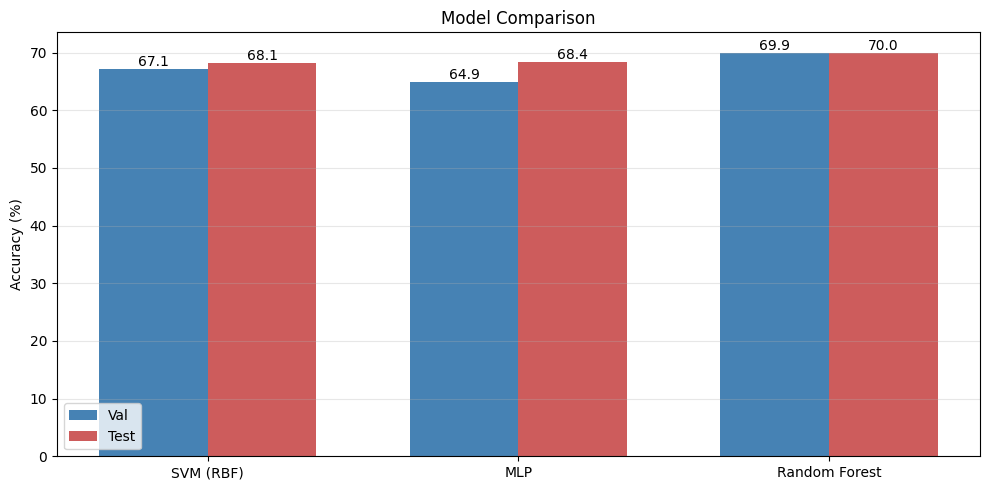


→ Best test model: Random Forest


In [14]:
results = pd.DataFrame({
    "Model":    ["SVM (RBF)", "MLP", "Random Forest"],
    "Val Acc":  [svm_val_acc*100,  mlp_val_acc*100,  rf_val_acc*100],
    "Test Acc": [svm_test_acc*100, mlp_test_acc*100, rf_test_acc*100],
    "Macro-F1 (Test)": [
        f1_score(y_test, svm.predict(X_test), average='macro', zero_division=0),
        f1_score(y_test, mlp.predict(X_test), average='macro', zero_division=0),
        f1_score(y_test, best_model.predict(X_test), average='macro', zero_division=0),
    ],
})

print(results.to_string(index=False))

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(results))
width = 0.35
ax.bar(x_pos - width/2, results["Val Acc"],  width, label="Val", color="steelblue")
ax.bar(x_pos + width/2, results["Test Acc"], width, label="Test", color="indianred")

for i, (v, t) in enumerate(zip(results["Val Acc"], results["Test Acc"])):
    ax.text(i - width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)
    ax.text(i + width/2, t + 0.5, f"{t:.1f}", ha='center', fontsize=10)

ax.set_xticks(x_pos); ax.set_xticklabels(results["Model"])
ax.set_ylabel("Accuracy (%)"); ax.set_title("Model Comparison")
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_COMPARE_PNG, dpi=120, bbox_inches='tight')
plt.show()

# Pick the best model for the deep-dive evaluation
best_name = results.loc[results["Test Acc"].idxmax(), "Model"]
name_to_model = {"SVM (RBF)": svm, "MLP": mlp, "Random Forest": best_model}
BEST_CLF = name_to_model[best_name]
print(f"\n→ Best test model: {best_name}")


## 15. Detailed evaluation of best model (classification report + F1)

In [15]:
y_pred = BEST_CLF.predict(X_test)

present_labels = sorted(np.unique(np.concatenate([y_test, y_pred])).tolist())
present_names  = le.inverse_transform(present_labels).tolist()

report_str = classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=present_names,
    zero_division=0
)
print(report_str)

report_dict = classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=present_names,
    zero_division=0,
    output_dict=True
)

macro_f1    = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"\nMacro-F1:    {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")


                            precision    recall  f1-score   support

               andean guan       1.00      0.67      0.80         3
            andean tinamou       0.33      0.50      0.40         2
    australian brushturkey       0.25      0.50      0.33         2
          band-tailed guan       0.50      0.67      0.57         3
         bartletts tinamou       0.40      0.33      0.36         6
                baudo guan       1.00      1.00      1.00         2
              bearded guan       0.80      0.80      0.80         5
        berlepschs tinamou       0.67      0.67      0.67         3
            biak scrubfowl       1.00      0.50      0.67         2
             black tinamou       0.33      0.25      0.29         4
  black-billed brushturkey       1.00      1.00      1.00         1
      black-capped tinamou       0.56      0.71      0.62         7
 black-fronted piping guan       1.00      1.00      1.00         1
 blue-throated piping guan       0.60      0.60

## 16. Confusion matrix

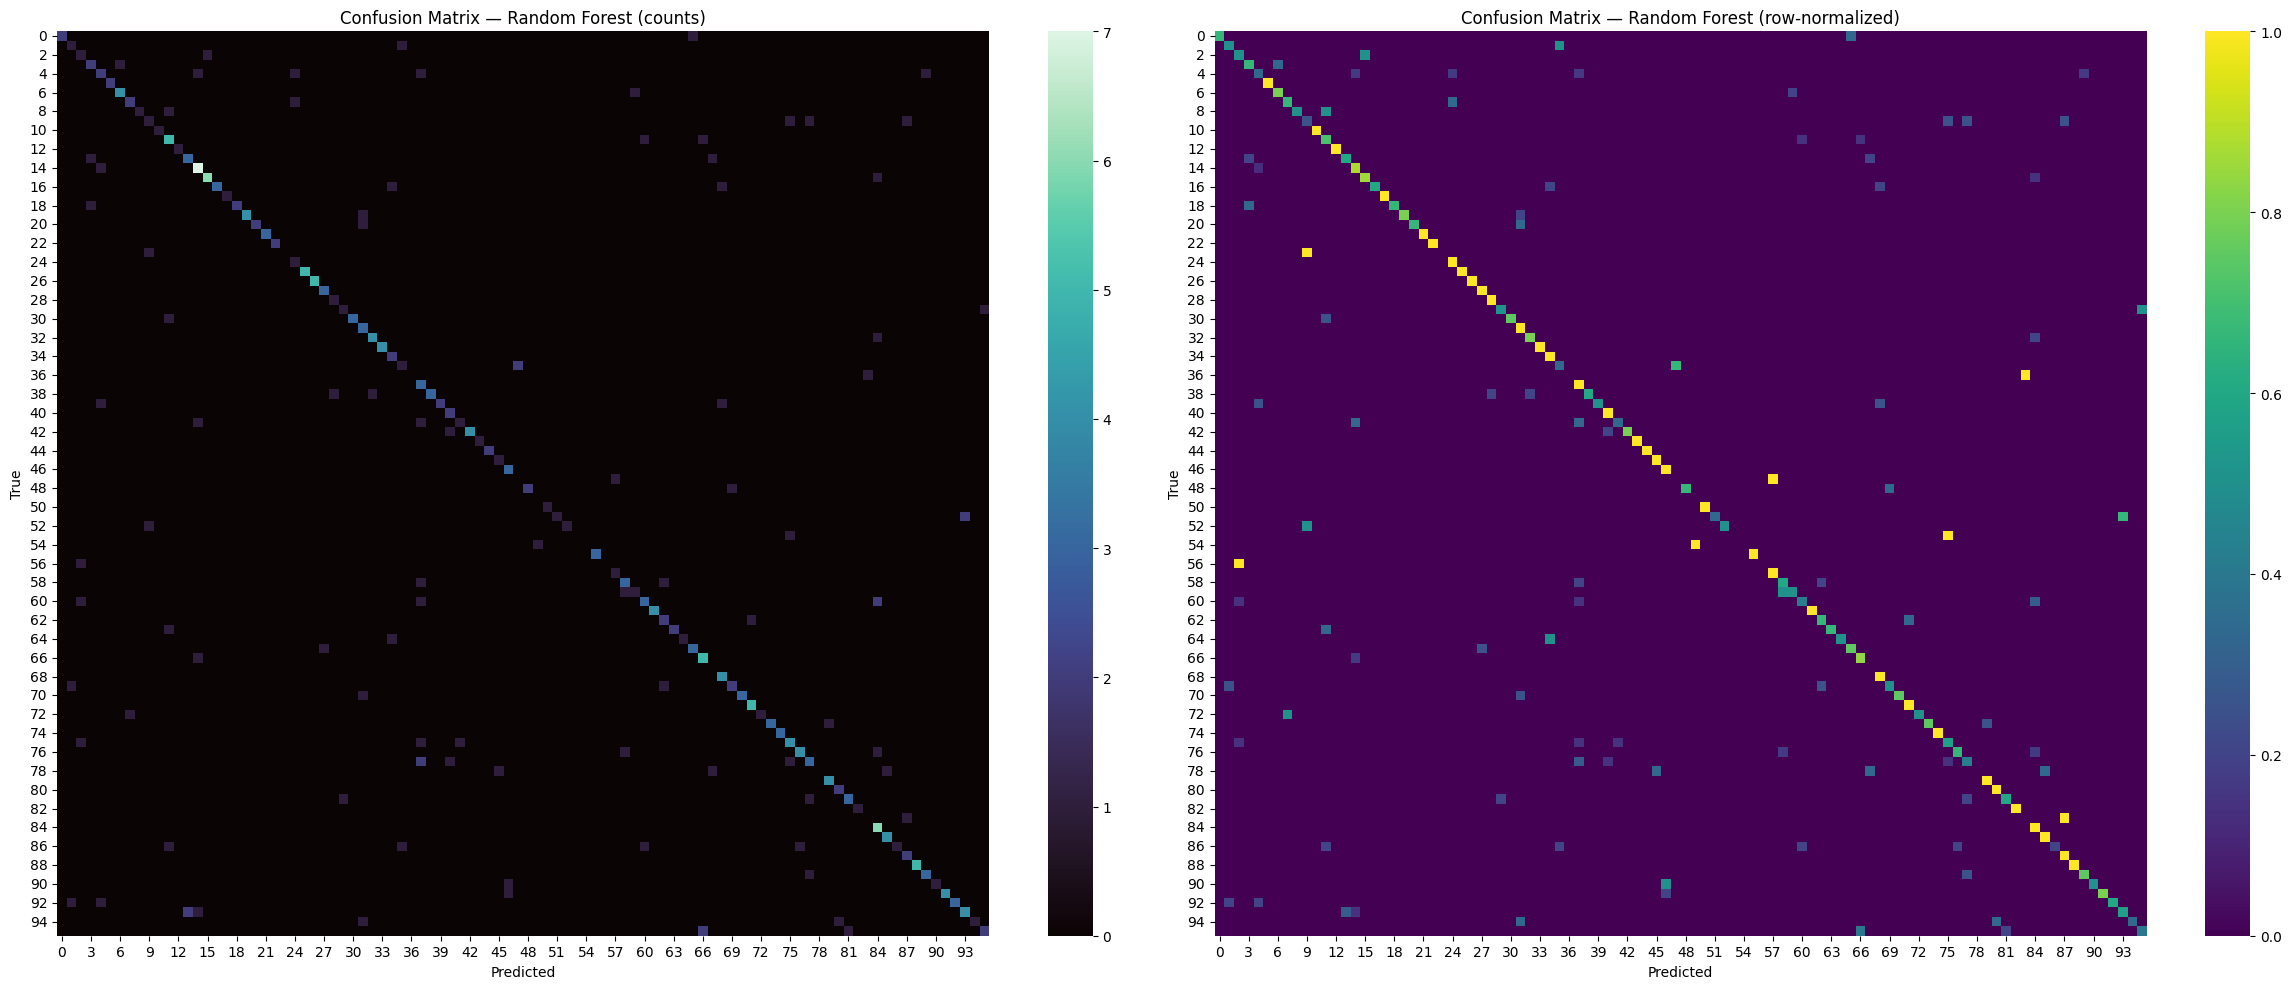

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
cm_norm = confusion_matrix(y_test, y_pred, labels=present_labels, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(cm, cmap="mako", ax=ax[0], cbar=True)
ax[0].set_title(f"Confusion Matrix — {best_name} (counts)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

sns.heatmap(cm_norm, cmap="viridis", ax=ax[1], cbar=True, vmin=0, vmax=1)
ax[1].set_title(f"Confusion Matrix — {best_name} (row-normalized)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(DRIVE_CM_PNG, dpi=120, bbox_inches='tight')
plt.show()


## 17. Per-species accuracy + save CSV

In [27]:
row_sums = cm.sum(axis=1)
per_class_acc = np.where(row_sums > 0, cm.diagonal() / np.maximum(row_sums, 1), 0.0)

df_acc = pd.DataFrame({
    "species": present_names,
    "n_test": row_sums,
    "accuracy": per_class_acc,
    "precision": [report_dict[n]['precision'] for n in present_names],
    "recall":    [report_dict[n]['recall']    for n in present_names],
    "f1":        [report_dict[n]['f1-score']  for n in present_names],
}).sort_values("accuracy", ascending=False).reset_index(drop=True)

df_acc.to_csv(DRIVE_REPORT_CSV, index=False)
print(f" Per-species metrics saved: {DRIVE_REPORT_CSV}")

print("\nTop 10 best classified:")
print(df_acc.head(10).to_string(index=False))
print("\nBottom 10 (paper error analysis candidates):")
print(df_acc.tail(10).to_string(index=False))

macro_acc = df_acc["accuracy"].mean()
print(f"\nMacro Accuracy: {macro_acc*100:.2f}%")

# Top most-confused pairs (for paper discussion)
confusions = []
for ti in range(cm.shape[0]):
    for pi in range(cm.shape[1]):
        if ti != pi and cm[ti, pi] > 0:
            confusions.append({
                "true": present_names[ti],
                "predicted_as": present_names[pi],
                "count": int(cm[ti, pi])
            })
df_conf = pd.DataFrame(confusions).sort_values("count", ascending=False)
df_conf.head(20).to_csv(f'{DRIVE_ROOT}/top_confusions.csv', index=False)
print(f"\n Top confusions saved for paper's error analysis.")
print(df_conf.head(10).to_string(index=False))


 Per-species metrics saved: /content/drive/MyDrive/BirdSound114_YAMNet/per_species_accuracy.csv

Top 10 best classified:
                   species  n_test  accuracy  precision  recall       f1
                baudo guan       2       1.0   1.000000     1.0 1.000000
  black-billed brushturkey       1       1.0   1.000000     1.0 1.000000
 black-fronted piping guan       1       1.0   1.000000     1.0 1.000000
              crested guan       3       1.0   0.750000     1.0 0.857143
      curve-billed tinamou       1       1.0   0.500000     1.0 0.666667
           chilean tinamou       2       1.0   1.000000     1.0 1.000000
chestnut-winged chachalaca       3       1.0   1.000000     1.0 1.000000
         dusky-legged guan       3       1.0   0.428571     1.0 0.600000
         cinereous tinamou       1       1.0   0.333333     1.0 0.500000
      collared brushturkey       5       1.0   1.000000     1.0 1.000000

Bottom 10 (paper error analysis candidates):
                 species  n_te

## 18. Save consolidated metrics (paper's Table 1)

In [26]:
final_metrics = {
    "config": {
        "seed": SEED,
        "yamnet_sr": YAMNET_SR,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
        "test_size": TEST_SIZE,
        "svm_C": SVM_C, "svm_gamma": SVM_GAMMA,
        "mlp_hidden": list(MLP_HIDDEN), "mlp_max_iter": MLP_MAX_ITER,
        "rf_best_params": str(rf_best_params),
    },
    "dataset": {
        "num_classes": int(NUM_CLASSES),
        "n_train": int(len(y_train)),
        "n_val":   int(len(y_val)),
        "n_test":  int(len(y_test)),
        "embedding_dim": 1024,
    },
    "results": {
        "svm":     {"val_acc": float(svm_val_acc),  "test_acc": float(svm_test_acc)},
        "mlp":     {"val_acc": float(mlp_val_acc),  "test_acc": float(mlp_test_acc)},
        "rf":      {"val_acc": float(rf_val_acc),   "test_acc": float(rf_test_acc)},
        "best_model": best_name,
        "best_test_acc_macro": float(macro_acc),
        "best_macro_f1": float(macro_f1),
        "best_weighted_f1": float(weighted_f1),
    }
}

with open(DRIVE_METRICS, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(json.dumps(final_metrics, indent=2))
print(f"\n All metrics saved to {DRIVE_METRICS}")


{
  "config": {
    "seed": 42,
    "yamnet_sr": 16000,
    "min_samples_per_class": 5,
    "test_size": 0.15,
    "svm_C": 10,
    "svm_gamma": "scale",
    "mlp_hidden": [
      512,
      256
    ],
    "mlp_max_iter": 300,
    "rf_best_params": "loaded from cache"
  },
  "dataset": {
    "num_classes": 100,
    "n_train": 1489,
    "n_val": 319,
    "n_test": 320,
    "embedding_dim": 1024
  },
  "results": {
    "svm": {
      "val_acc": 0.670846394984326,
      "test_acc": 0.68125
    },
    "mlp": {
      "val_acc": 0.6489028213166145,
      "test_acc": 0.684375
    },
    "rf": {
      "val_acc": 0.6990595611285266,
      "test_acc": 0.7
    },
    "best_model": "Random Forest",
    "best_test_acc_macro": 0.6734002976190476,
    "best_macro_f1": 0.6537020036028357,
    "best_weighted_f1": 0.6955108169318212
  }
}

 All metrics saved to /content/drive/MyDrive/BirdSound114_YAMNet/final_metrics.json


## 19. Prediction pipeline (all 3 models + top-k)

Loads everything from Drive so this works even in a fresh session where nothing was just trained.

In [25]:
# Reload YAMNet if not already loaded
try:
    yamnet
except NameError:
    print("Loading YAMNet for inference...")
    yamnet = hub.load("https://tfhub.dev/google/yamnet/1")
    print(" YAMNet loaded.")

# Reload artifacts from Drive
svm         = joblib.load(DRIVE_SVM_MODEL)
mlp         = joblib.load(DRIVE_MLP_MODEL)
best_model  = joblib.load(DRIVE_RF_MODEL)
scaler      = joblib.load(DRIVE_SCALER)
le          = joblib.load(DRIVE_LABEL_ENC)

def extract_yamnet_embedding(audio_path):
    y, sr = librosa.load(audio_path, sr=YAMNET_SR)
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)
    scores, embeddings, _ = yamnet(waveform)
    emb = np.mean(embeddings.numpy(), axis=0)
    return emb.reshape(1, -1)

def top_k_probs(model, emb_scaled, k=5):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(emb_scaled)[0]
        idx = np.argsort(probs)[::-1][:k]
        species = le.inverse_transform(idx)
        return list(zip(species, probs[idx]))
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(emb_scaled)[0]
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        idx = np.argsort(scores_norm)[::-1][:k]
        species = le.inverse_transform(idx)
        return list(zip(species, scores_norm[idx]))
    else:
        raise ValueError(f"Model {type(model)} not supported.")

def predict_species(audio_path, k=5):
    emb = extract_yamnet_embedding(audio_path)
    emb_scaled = scaler.transform(emb)

    print(f"\n Predicting: {audio_path}")
    print("=" * 50)

    for name, model in [("SVM", svm), ("MLP", mlp), ("Random Forest", best_model)]:
        pred = model.predict(emb_scaled)[0]
        species = le.inverse_transform([pred])[0]
        print(f"\n{name}: {species}")
        print(f"  Top-{k}:")
        for sp, p in top_k_probs(model, emb_scaled, k=k):
            print(f"    {sp:<40s} {p*100:.2f}%")

    return {"SVM": svm.predict(emb_scaled)[0],
            "MLP": mlp.predict(emb_scaled)[0],
            "RF":  best_model.predict(emb_scaled)[0]}




In [28]:

predict_species("/content/t1.mp3")


 Predicting: /content/t1.mp3

SVM: dusky-legged guan
  Top-5:
    dusky-legged guan                        20.89%
    orange-footed scrubfowl                  5.44%
    rufous-vented chachalaca                 5.42%
    andean guan                              4.82%
    band-tailed guan                         3.95%

MLP: dusky-legged guan
  Top-5:
    dusky-legged guan                        91.33%
    orange-footed scrubfowl                  1.60%
    white-winged guan                        1.58%
    rufous-vented chachalaca                 1.56%
    band-tailed guan                         0.75%

Random Forest: dusky-legged guan
  Top-5:
    dusky-legged guan                        95.25%
    rufous-vented chachalaca                 0.75%
    orange-footed scrubfowl                  0.50%
    andean guan                              0.50%
    red-faced guan                           0.25%


{'SVM': np.int64(32), 'MLP': np.int64(32), 'RF': np.int64(32)}

## Notes: comparison with MobileNetV2 notebook (for the paper)

This YAMNet notebook and the MobileNetV2 notebook are two fundamentally different approaches to the same problem:

| Aspect | MobileNetV2 (Notebook 1) | YAMNet + Classical ML (this notebook) |
|--------|--------------------------|---------------------------------------|
| Input representation | 224×224 mel spectrogram (image) | 1024-dim YAMNet embedding (audio-native) |
| Pretraining domain | ImageNet (natural images) | AudioSet (audio events, incl. bird calls) |
| Model | End-to-end CNN + fine-tuning | Frozen encoder + shallow classifier |
| Trainable params | ~3M | ~10K–100K |
| Training time | 30 min – 2 hours | 1–5 min (after embedding extraction) |
| Bottleneck | GPU training | Embedding extraction (one-time) |

**Paper contribution angle:** systematic comparison of image-transfer vs audio-native-transfer for imbalanced bird sound classification.

**Cross-reference the two `final_metrics.json` files** (MobileNet and YAMNet) to compare macro-F1, per-species accuracy overlap, and which failure modes each approach has. That comparison IS the paper.

**Ablations you can now run (config change at the top of each notebook):**
1. **MobileNet vs YAMNet** — this is already done, just tabulate results
2. **MLP `max_iter=20` vs `max_iter=300`** — reproduces original bug, quantifies impact
3. **SVM with/without `class_weight='balanced'`** — measures imbalance handling
4. **RF grid search vs single config** — cost/benefit
5. **`MIN_SAMPLES_PER_CLASS` = 4 vs 5 vs 10** — how does class filtering affect macro-F1?
